<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Termodinamica/correcion_Termo4_jm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Python 4:  **Diagramas ST, PV, PT, VT y PVT**
<br>

### &nbsp; **Termodinamica:**

>  &nbsp; &nbsp; *Juan Manuel Cárdenas*


<br>

___

<br>

In [ ]:
# librerias
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants

**Ejercicio 4.33.** Para n moles de un gas ideal (monoatómico y diatómico) realice diagramas ST, PV, PT, VT y superficie PVT, de los siguientes procesos, teniendo en cuenta:

Para gas **Monoatomico**: <br>
> $ c_v = \frac{3}{2} nR $ <br>
> $ c_p = \frac{5}{2} nR$ <br>
> $ γ = 5/3 $ <br>

Para gas **Diatomico**: <br>
> $ c_v = \frac{5}{2} nR$ <br>
> $ c_p = \frac{7}{2} nR$ <br>
> $ γ = 7/5 $ <br>

constante de los gases ideales $R = 8.3144 [\frac{J}{K * mol}]$ para n moles dados.

In [ ]:
# definiendo parametros
cv_mono = 3/2 ; cv_di = 5/2 # capacidad calorifica v cte
cp_mono = 5/2 ; cp_di = 7/2 # capacidad calorifica p cte
γ_mono = 5/3  ; γ_di = 7/5  # parametro γ



R = constants.R.value # constante R [J/K.mol]
n = 10 # moles arbitrarias
name =['monoatomic', 'diatomic']

cv_list = [cv_mono*n*R, cv_di*n*R]
cp_list = [cp_mono*n*R, cp_di*n*R]
γ_list = [γ_mono, γ_di]    # γ para mono y diatomico

# **Procesos:**

###**Adiabáticos**: Partiendo de  $ P V^{γ}= cte $ y $ΔQ=0$ <br>
> PV:
>  $$ P = cte V^{-γ}$$
>
> VT:
>  $$ T = \frac{cte}{nR} V^{1-γ}$$
>  $$ V = (\frac{nR}{cte}T)^{1/(1-γ)} $$
>
> PT:
>  $$ T = \frac{cte^{1/γ}}{nR} P^{(γ-1)/γ}$$
>  $$ P =  (\frac{nR}{cte^{1/γ}} T)^{γ/(γ-1)}$$
>
> ST:
> $$ dS = dQ_R / T $$
> $$ dS = 0 $$
> $$ S = constant $$




para todos los diagramas se crea un rango de la variable independiente



In [ ]:
cte = 1 # cte arbitraria (P*V^{γ} = cte)


# para PV
V = np.linspace(0.5, 10, 60) # rango de volumen
P = [ cte*V**(-γ) for γ in γ_list ] # presion asociada

# para VT
T = np.linspace(5,300,400)  # rango de temperaturas
V_ = [ (n*R*T/cte)**(1/(1-γ)) for γ in γ_list ]

# para PT
P_ = [ ( n*R*T/((cte)**(1/γ)) )**(γ/(γ-1)) for γ in γ_list ]

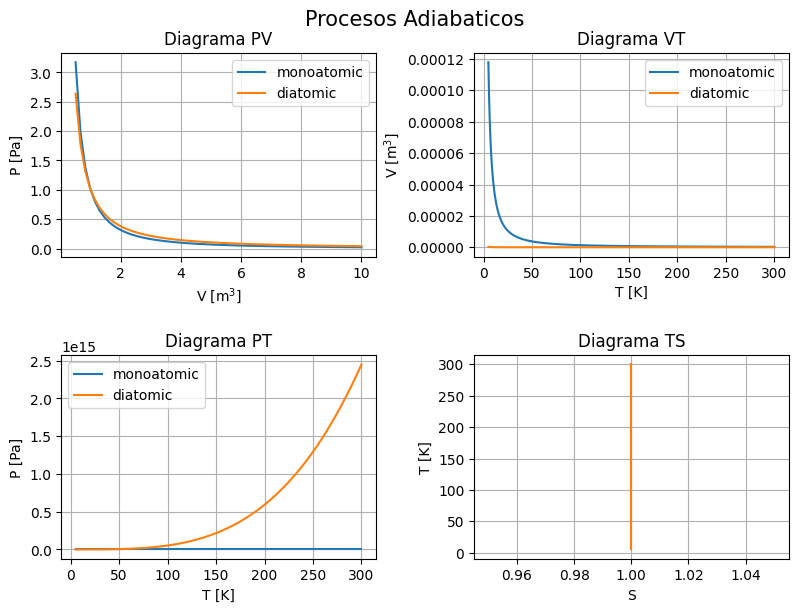

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols= 2, figsize=(8,6))
fig.suptitle('Procesos Adiabaticos', fontsize=15)
fig.tight_layout( h_pad=5, w_pad=4 ) # espacio vertical-horizontal

for i in range(len(γ_list)):
  ax[0,0].plot(V, P[i], label =f'{name[i]}') # pv
  ax[0,1].plot(T, V_[i], label =f'{name[i]}') #vt
  ax[1,0].plot(T, P_[i], label =f'{name[i]}') #pt
  ax[1,1].plot(np.ones(len(T)),T) #ts

ax[0,0].set_title('Diagrama PV')
ax[0,0].set_ylabel("P [Pa]")
ax[0,0].set_xlabel("V [m$^3$]")
ax[0,0].grid()
ax[0,0].legend()

ax[0,1].set_title('Diagrama VT')
ax[0,1].set_ylabel("V [m$^3$]")
ax[0,1].set_xlabel("T [K]")
ax[0,1].grid()
ax[0,1].legend()

ax[1,0].set_title('Diagrama PT')
ax[1,0].set_ylabel("P [Pa]")
ax[1,0].set_xlabel("T [K]")
ax[1,0].grid()
ax[1,0].legend()

ax[1,1].set_title('Diagrama TS')
ax[1,1].set_xlabel("S")
ax[1,1].set_ylabel("T [K]")
ax[1,1].grid()

# ax[0, 0].text(0, 0, r'$P \propto \cdot V^{-γ}$',
#               fontsize=15, ha='center', va='center')
plt.show()




###**Isotérmicos**: $T$ cte,

> PV:
> $$ P = n R T_o V^{-1}$$
>
> VT:
> $$ V = n R T_o P^{-1}$$
>
> PT:
> $$ P = n R T_o V^{-1}$$
>
> ST:
> $$ dS= dQ / T_o$$
> $$ dS= (c_v dT + P dV ) / T_o$$
>
> Con $P/T=nRV^{-1}$
>
> $$ S= \frac{nR}{T_o}\int V^{-1} dV  $$
> $$ S= \frac{nR}{T_o}\ln \frac{V}{V_o}  $$

teniendo en cuenta $dT = 0$ isotermico


In [ ]:
To = 273.16 # temperatura cte

# para pv y pt
P_isot = n*R*To*V**(-1) # independiente de γ

# para vt
P = np.linspace(0.1,100,100) # volumen depende de presion
V_isot =  n*R*To*P**(-1)

# para TS
S_isot_1 = n*R* np.log(V/V[0])
S_isot_2 = -n*R* np.log(P_isot/P_isot[0])

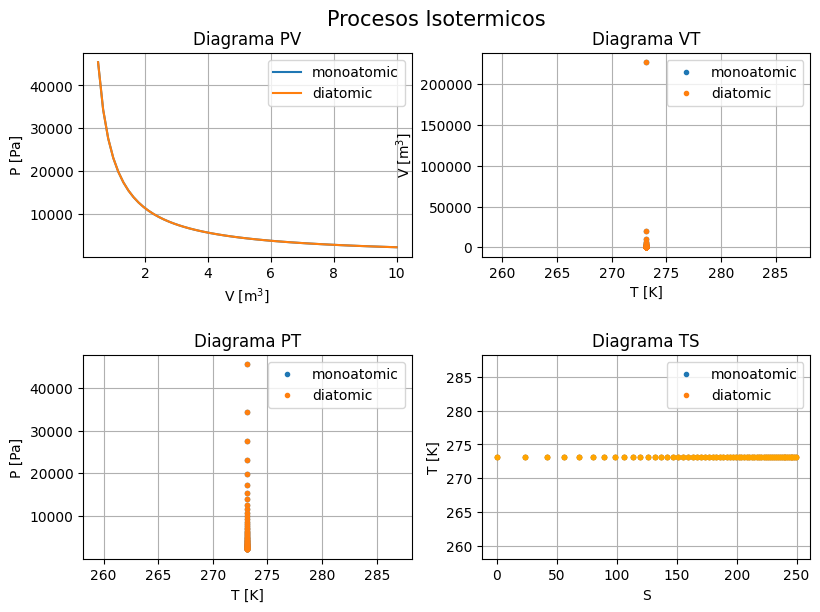

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols= 2, figsize=(8,6))
fig.suptitle('Procesos Isotermicos', fontsize=15)
fig.tight_layout( h_pad=5, w_pad=2 ) # espacio vertical-horizontal

for i in range(len(γ_list)):
  ax[0,0].plot(V, P_isot, label =f'{name[i]}') # pv
  ax[0,1].plot(To*np.ones(len(V_isot)), V_isot, '.' , label =f'{name[i]}') # vt
  ax[1,0].plot(To*np.ones(len(P_isot)), P_isot, '.' , label =f'{name[i]}') # pt
  ax[1,1].plot(S_isot_1, To*np.ones(len(S_isot_1)), '.', label =f'{name[i]}') #ST
  ax[1,1].plot(S_isot_2, To*np.ones(len(S_isot_2)), '.', c='orange') #ST

ax[0,0].set_title('Diagrama PV')
ax[0,0].set_ylabel("P [Pa]")
ax[0,0].set_xlabel("V [m$^3$]")
ax[0,0].grid()
ax[0,0].legend()

ax[0,1].set_title('Diagrama VT')
ax[0,1].set_ylabel("V [m$^3$]")
ax[0,1].set_xlabel("T [K]")
ax[0,1].grid()
ax[0,1].legend()

ax[1,0].set_title('Diagrama PT')
ax[1,0].set_ylabel("P [Pa]")
ax[1,0].set_xlabel("T [K]")
ax[1,0].grid()
ax[1,0].legend()

ax[1,1].set_title('Diagrama TS')
ax[1,1].set_xlabel("S")
ax[1,1].set_ylabel("T [K]")
ax[1,1].legend()
ax[1,1].grid()

plt.show()


### **Isocóricos**: $V$ cte, $dV=0$
> PV:
> $$ P = n R T V_o^{-1}$$
>
> VT:
> $$ V_o = n R T P^{-1}$$
>
> PT:
> $$ P = n R V_o^{-1}T $$
>
> TS:
> $$ dS= dQ / T$$
> $$ dS= (c_v dT +P dV) / T$$
> $$ S= c_v \ln \frac{T}{T_o}$$




In [ ]:
Vo = 1 # V cte

# para PT
P_isoco = n*R*Vo**-1*T
V_isoco = Vo * np.ones(len(T))
S_isoco = [cv* np.log(T/T[0]) for cv in cv_list] # depende de mono-diatom

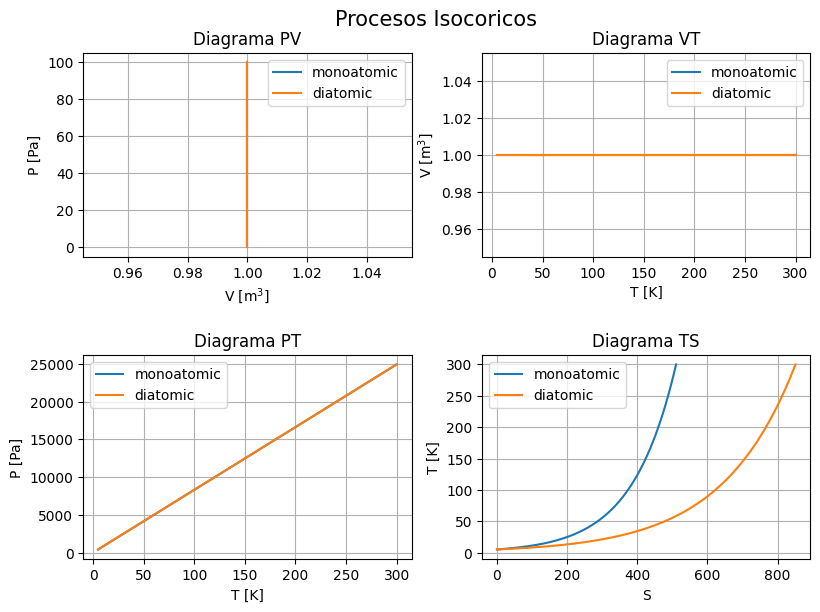

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols= 2, figsize=(8,6))
fig.suptitle('Procesos Isocoricos', fontsize=15)
fig.tight_layout( h_pad=5, w_pad=2 ) # espacio vertical-horizontal

for i in range(len(γ_list)):
  ax[0,0].plot(Vo*np.ones(len(P)) , P,label =f'{name[i]}') # pv
  ax[0,1].plot(T, Vo*np.ones(len(T)) , label =f'{name[i]}') # vt
  ax[1,0].plot(T, P_isoco, label =f'{name[i]}') # pt
  ax[1,1].plot(S_isoco[i], T, label =f'{name[i]}') #ST


ax[0,0].set_title('Diagrama PV')
ax[0,0].set_ylabel("P [Pa]")
ax[0,0].set_xlabel("V [m$^3$]")
ax[0,0].grid()
ax[0,0].legend()

ax[0,1].set_title('Diagrama VT')
ax[0,1].set_ylabel("V [m$^3$]")
ax[0,1].set_xlabel("T [K]")
ax[0,1].grid()
ax[0,1].legend()

ax[1,0].set_title('Diagrama PT')
ax[1,0].set_ylabel("P [Pa]")
ax[1,0].set_xlabel("T [K]")
ax[1,0].grid()
ax[1,0].legend()

ax[1,1].set_title('Diagrama TS')
ax[1,1].set_xlabel("S")
ax[1,1].set_ylabel("T [K]")
ax[1,1].legend()
ax[1,1].grid()


plt.show()

In [ ]:
# Parámetros de ejemplo
n = 1.0
R = 8.314
Vo = 1.0  # Volumen constante

# Superficie PVT isocórica

# Crear una malla 2D de V y T
P, T = np.meshgrid(P_isoco, T)

# Calcular los valores de P en función de V y T (P isocórico)


# Crear una figura 3D
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Superficie PVT isocórica')

# Crear la superficie a partir de los datos
surf = ax.plot_surface(V, T, P, cmap='viridis', label='Superficie XYZ')

ax.set_zlabel('P')
ax.set_xlabel('V')
ax.set_ylabel('T')

# Añadir una barra de color
# fig.colorbar(surf, label='P')

plt.show()

### **Isobáricos**: $P$ cte,  $dP=0$
> PV:
> $$ P_o = n R T V^{-1}$$
>
> VT:
> $$ V = n R  P_o^{-1} T$$
>
> PT:
> $$ P_o = n R V^{-1}T $$
>
> ST:
> $$ dS= dQ / T$$
> $$ dS= (dU - dW) / T$$
> $$ dS= (c_P dT - V dP) / T$$
> $$ S= c_p \ln \frac{T}{T_o}$$



In [ ]:
Po = 1 # P cte

# para VT
V_isobar = n*R*Po**(-1)*T

# para TS
S_isobar = [ cp* np.log(T/T[0]) for cp in cp_list]

# p cte
P_isobar = Po * np.ones(len(T))

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols= 2, figsize=(8,6))
fig.suptitle('Procesos Isobaricos', fontsize=15)
fig.tight_layout( h_pad=5, w_pad=3 ) # espacio vertical-horizontal

for i in range(len(γ_list)):
  ax[0,0].plot(V, Po*np.ones(len(V)), label =f'{name[i]}') # pv
  ax[0,1].plot(T, V_isobar, label =f'{name[i]}') # vt
  ax[1,0].plot(T, Po*np.ones(len(T)), label =f'{name[i]}') #pt
  ax[1,1].plot(S_isobar[i], T, label =f'{name[i]}') #ST

ax[0,0].set_title('Diagrama PV')
ax[0,0].set_ylabel("P [Pa]")
ax[0,0].set_xlabel("V [m$^3$]")
ax[0,0].grid()
ax[0,0].legend()

ax[0,1].set_title('Diagrama VT')
ax[0,1].set_ylabel("V [m$^3$]")
ax[0,1].set_xlabel("T [K]")
ax[0,1].grid()
ax[0,1].legend()

ax[1,0].set_title('Diagrama PT')
ax[1,0].set_ylabel("P [Pa]")
ax[1,0].set_xlabel("T [K]")
ax[1,0].grid()
ax[1,0].legend()

ax[1,1].set_title('Diagrama TS')
ax[1,1].set_xlabel("S")
ax[1,1].set_ylabel("T [K]")
ax[1,1].grid()
ax[1,1].legend()

plt.show()

In [ ]:
# superficie PVT isobar

x = V_isobar
y = T
X, Y = np.meshgrid(x, y)

# definir matriz Z_XY, P en función de V y T
Z_XY = np.outer(P_isobar, np.ones(len(V_isobar)))

# Crear una figura 3D
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Superficie PVT isobarica')
surf = ax.plot_surface(X, Y, Z_XY, cmap='viridis', label='Superficie XYZ')

ax.set_box_aspect([1, 1, 1])
ax.set_zlabel('P')
ax.set_xlabel('V')
ax.set_ylabel('T')
plt.show()

# Añadir una barra de color
# fig.colorbar(surf, label='P')

### Comparacion TS isocor>isobar

In [ ]:
# comparacion isobar-isocor
bs = ['blue','gray']
rs = ['gray','red']
plt.figure(figsize=(4,2))
plt.title('Comparacion pendiente TS iso(baric-coric)')

for i in range(len(γ_list)):
  plt.plot(S_isobar[i], T, color = rs[i], label = f'{name[i]} Isobar')
  plt.plot(S_isoco[i], T, color = bs[i], label = f'{name[i]} Isocor')

plt.grid()
plt.legend()
plt.show()


### Conclusiones

El signo y la pendiente depende de cada caso, pero en general si la curva de los diagramas es creciente el signo de la pendiente es positivo, por el contrario si es decreciente será negativo, en los casos constantes (digramas horizontales) el valor es 0, mientras que para los verticales la pendiente tiende a infinito.